# Analisis Klaster Gempa (K-Means + Silhouette)
**Tujuan:**  
1. Melakukan klastering gempa menggunakan K-Means.  
2. Menentukan jumlah klaster *k* terbaik menggunakan *silhouette score*.  
3. Menandai tingkat keparahan klaster berdasarkan *magnitude* (dan kedalaman).  
4. Menyimpan model & scaler untuk dipakai di aplikasi Streamlit.  

**File input:** `katalog_gempa.csv` (sudah Anda upload ke environment).  
**Output:**  
- `kmeans_pipeline.joblib` (pipeline berisi scaler + KMeans),  
- `cluster_info.csv` (centroid & label),  
- Visualisasi peta interaktif dengan Plotly.

In [1]:
# VERIFICATION: Check if nbformat is installed
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}\n")

try:
    import nbformat
    print(f"✅ nbformat is installed: version {nbformat.__version__}")
except ImportError:
    print("❌ nbformat is NOT installed!")
    print("   Run: pip install nbformat")

try:
    import plotly
    print(f"✅ plotly is installed: version {plotly.__version__}")
except ImportError:
    print("❌ plotly is NOT installed!")


Python executable: c:\DEV\TRY\venv\Scripts\python.exe
Python version: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]

✅ nbformat is installed: version 5.10.4
✅ plotly is installed: version 6.5.0


In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
import joblib
import plotly.express as px

print("Libraries imported.")

Libraries imported.


In [3]:
path = "katalog_gempa_v2.tsv"
if not os.path.exists(path):
    raise FileNotFoundError(f"File not found: {path}")

# Baca file TSV
df = pd.read_csv(path, sep="\t")
print("Raw columns:", list(df.columns)[:15])

# Tetapkan kolom sesuai dataset
col_map = {
    'time': 'datetime',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'depth': 'depth',
    'mag': 'magnitude'
}

# Rename kolom agar konsisten
df = df.rename(columns={
    col_map['time']: 'time',
    col_map['latitude']: 'latitude',
    col_map['longitude']: 'longitude',
    col_map['depth']: 'depth',
    col_map['mag']: 'mag'
})

# Konversi tipe data
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')   

# Drop baris yang tidak lengkap
df = df.dropna(subset=['time', 'latitude', 'longitude', 'mag']).reset_index(drop=True)

print(f"Loaded {len(df)} earthquake records with columns: {list(df.columns)}")
df.head()

C:\Users\farro\AppData\Local\Temp\ipykernel_8452\2103782978.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="\t")


Raw columns: ['eventID', 'datetime', 'latitude', 'longitude', 'magnitude', 'mag_type', 'depth', 'phasecount', 'azimuth_gap', 'location', 'agency', 'datetimeFM', 'latFM', 'lonFM', 'magFM']
Loaded 131131 earthquake records with columns: ['eventID', 'time', 'latitude', 'longitude', 'mag', 'mag_type', 'depth', 'phasecount', 'azimuth_gap', 'location', 'agency', 'datetimeFM', 'latFM', 'lonFM', 'magFM', 'magTypeFM', 'depthFM', 'phasecountFM', 'AzGapFM', 'scalarMoment', 'Mrr', 'Mtt', 'Mpp', 'Mrt', 'Mrp', 'Mtp', 'varianceReduction', 'doubleCouple', 'clvd', 'strikeNP1', 'dipNP1', 'rakeNP1', 'strikeNP2', 'dipNP2', 'rakeNP2', 'azgapFM', 'misfit']


,eventID,time,latitude,longitude,mag,mag_type,depth,phasecount,azimuth_gap,location,...,doubleCouple,clvd,strikeNP1,dipNP1,rakeNP1,strikeNP2,dipNP2,rakeNP2,azgapFM,misfit
0,bmg2008vkye,2008-11-01 00:31:25.143741+00:00,-0.604440,98.895531,2.989742,MLv,20,6.0,146.70738,"Southern Sumatra, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bmg2008vlag,2008-11-01 01:34:29.660856+00:00,-6.611860,129.387220,5.507549,mb,30,62.0,45.46764,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bmg2008vlaj,2008-11-01 01:38:14.802129+00:00,-3.650586,127.990680,3.539674,MLv,5,4.0,331.97404,"Seram, Indonesia",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bmg2008vlbt,2008-11-01 02:20:05.909515+00:00,-4.198925,128.097000,2.424314,MLv,5,5.0,326.37993,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bmg2008vlcd,2008-11-01 02:32:18.756155+00:00,-4.091891,128.200470,2.410045,MLv,10,5.0,314.65474,Banda Sea,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Features used for clustering (Risk Profiling Only): ['mag', 'depth']
Total data points used: 131131

--- 📊 Statistik Data Feature ---


,count,mean,std,min,25%,50%,75%,max
mag,131131.0,3.512964,0.830521,0.191153,2.90871,3.452434,4.092975,7.902198
depth,131131.0,49.661964,79.716301,0.000000,10.00000,16.000000,54.000000,750.000000



--- 🌍 Distribusi Awal Risiko (Magnitude vs Depth) ---


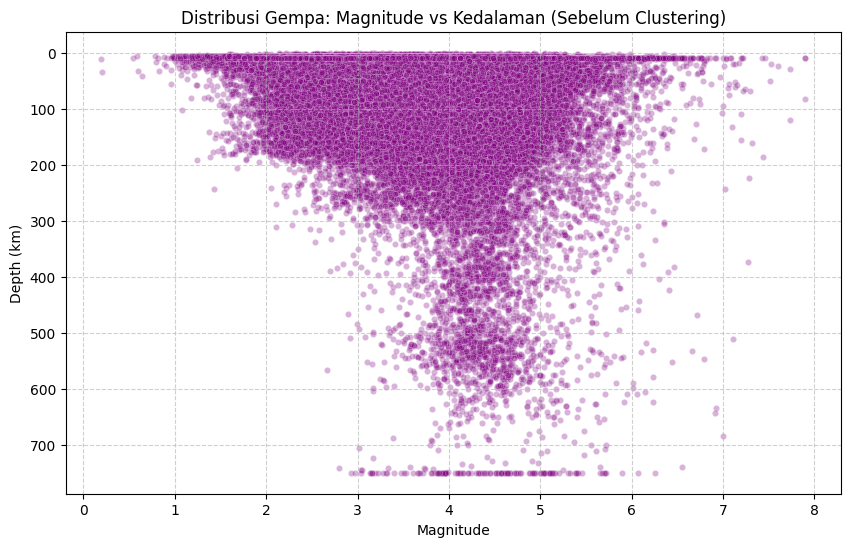

,mag,depth
0,2.989742,20
1,5.507549,30
2,3.539674,5
3,2.424314,5
4,2.410045,10


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kita akan gunakan fitur fisik SAJA untuk clustering risiko: Magnitude dan Depth
# Latitude dan Longitude DIHAPUS agar tidak ada bias geografis.

features = ['mag', 'depth']

# Pastikan tidak ada nilai NaN sebelum proses klastering
X = df[features].dropna().copy()

print("Features used for clustering (Risk Profiling Only):", features)
print("Total data points used:", len(X))

print("\n--- 📊 Statistik Data Feature ---")
display(X.describe().T)

print("\n--- 🌍 Distribusi Awal Risiko (Magnitude vs Depth) ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='mag', y='depth', alpha=0.3, color='purple', s=20)
plt.title('Distribusi Gempa: Magnitude vs Kedalaman (Sebelum Clustering)')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.gca().invert_yaxis() # Kedalaman makin besar makin ke bawah grafiknya
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(X.head())


Menstandarisasi fitur dan mencari jumlah klaster terbaik (k)...
Proses ini akan memakan waktu beberapa menit...



🔍 Testing k values:   0%|          | 0/4 [00:00<?, ?it/s]

   k=2: Silhouette=0.4471 | Inertia=1869
   k=3: Silhouette=0.4557 | Inertia=1147
   k=4: Silhouette=0.4687 | Inertia=832
   k=5: Silhouette=0.4234 | Inertia=612


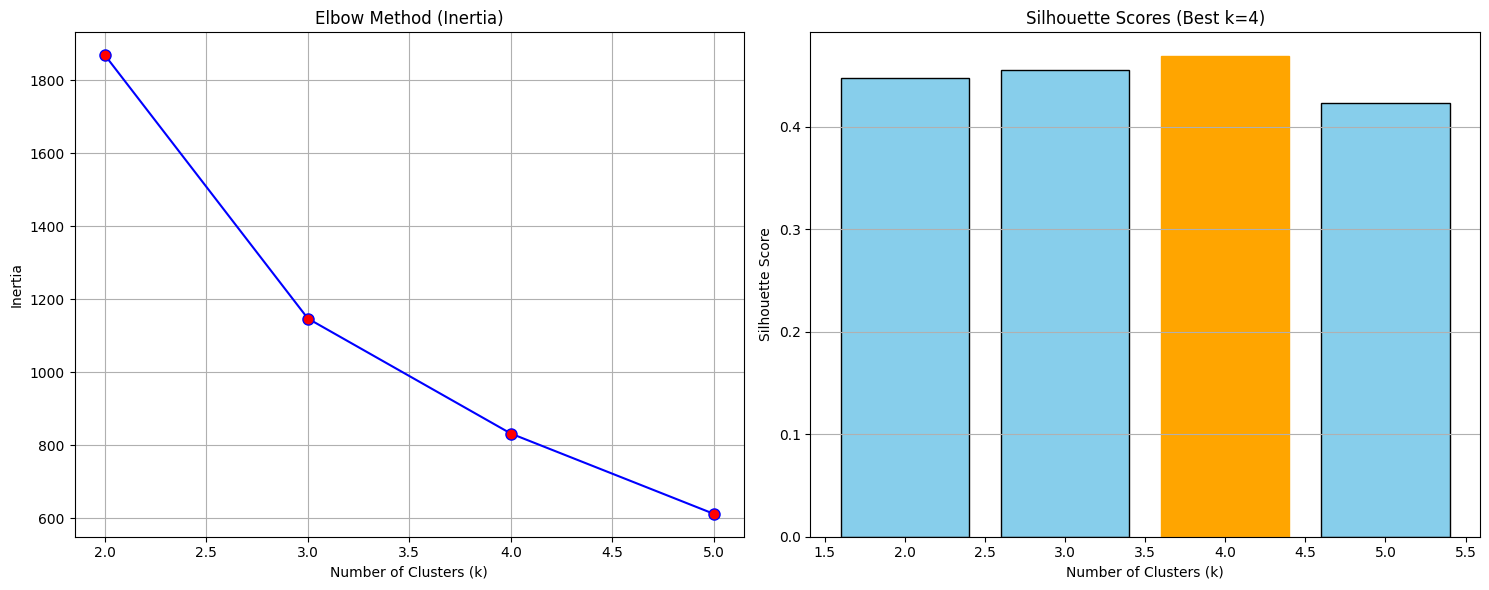


✅ Best k detected: 4 (Silhouette Score: 0.4687)


In [ ]:
from tqdm.notebook import tqdm
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Menstandarisasi fitur dan mencari jumlah klaster terbaik (k)...")
print("Proses ini akan memakan waktu beberapa menit...\n")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

K_range = range(2, 8)
sil_scores = []
inertias = []

pbar = tqdm(
    K_range,
    desc="🔍 Testing k values",
    dynamic_ncols=True,
    file=sys.stdout,
    mininterval=0.1,
    leave=True
)

for k in pbar:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3)
    labels = kmeans.fit_predict(X_scaled)

    # Calculate metrics
    score = silhouette_score(X_scaled, labels)
    inertia = kmeans.inertia_
    
    sil_scores.append(score)
    inertias.append(inertia)

    pbar.set_postfix_str(f"k={k} sil={score:.4f} inertia={inertia:.0f}")
    tqdm.write(f"   k={k}: Silhouette={score:.4f} | Inertia={inertia:.0f}")

# Determine best_k based on max silhouette
# Note: Elbow method is visual, so we stick to silhouette for auto-selection
best_score_idx = sil_scores.index(max(sil_scores))
best_k = K_range[best_score_idx]

# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Elbow Method (Inertia)
ax1.plot(K_range, inertias, 'bo-', markerfacecolor='red', markersize=8)
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

# Plot 2: Silhouette Score
bars = ax2.bar(K_range, sil_scores, color='skyblue', edgecolor='black')
bars[best_score_idx].set_color('orange') # Highlight best k
ax2.set_title(f'Silhouette Scores (Best k={best_k})')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Best k detected: {best_k} (Silhouette Score: {max(sil_scores):.4f})")


In [9]:
# --- FIT MODEL FINAL DENGAN BEST K ---
print(f"Fitting final KMeans model with k={best_k}...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Simpan label ke DataFrame utama
df['cluster'] = labels
print("✅ Cluster labels assigned to df['cluster']")


Fitting final KMeans model with k=4...
✅ Cluster labels assigned to df['cluster']


In [10]:
# --- ANALISIS CENTROID & PELABELAN BARU ---
# Hitung rata-rata fitur tiap klaster (Centroid manual dari data asli)
cluster_summary = df.groupby('cluster').agg({
    'mag': 'mean',
    'depth': 'mean',
    'latitude': 'mean', 
    'longitude': 'mean'
}).reset_index()

# --- HITUNG SEVERITY SCORE DENGAN PEMBOBOTAN ---
# Ambil Global Min/Max untuk normalisasi yang adil
mag_min, mag_max = df['mag'].min(), df['mag'].max()
depth_min, depth_max = df['depth'].min(), df['depth'].max()

def calculate_weighted_severity(row):
    # Normalisasi Magnitude (0-1), semakin besar semakin bahaya
    m_norm = (row['mag'] - mag_min) / (mag_max - mag_min)
    
    # Normalisasi Depth (0-1)
    # Semakin DANGKAL (kecil) semakin bahaya, jadi kita pakai inv_norm
    d_norm = (row['depth'] - depth_min) / (depth_max - depth_min)
    d_inv_norm = 1.0 - d_norm
    
    # Formula Dosen: 70% Mag, 30% Shallow Depth
    score = (0.7 * m_norm) + (0.3 * d_inv_norm)
    return score

cluster_summary['severity_score'] = cluster_summary.apply(calculate_weighted_severity, axis=1)

# --- RE-LABELING BERDASARKAN SKOR ---
# Urutkan dari score terendah (Low) ke tertinggi (Very High)
cluster_summary = cluster_summary.sort_values('severity_score', ascending=True).reset_index(drop=True)

# Mapping Label Baru
level_names = ['Low', 'Moderate', 'High', 'Very High'] # Asumsi k=4
if best_k != 4:
    # Fallback jika k bukan 4, generate nama dinamis
    level_names = [f'Level {i+1}' for i in range(best_k)]

cluster_remap = {}
print("Cluster ID Remapping (Original -> New Risk Label):")

for new_id, row in cluster_summary.iterrows():
    original_id = int(row['cluster'])
    label_name = level_names[min(new_id, len(level_names)-1)]
    cluster_remap[original_id] = {
        'new_id': new_id,
        'label': label_name,
        'severity': row['severity_score']
    }
    print(f"  Orig Cluster {original_id} -> New ID {new_id} ({label_name}) | Score: {row['severity_score']:.4f}")
    
    # Verify: 0 should be Low, 3 should be Very High (for k=4)
    if best_k == 4:
        if new_id == 0 and label_name != 'Low':
            print(f"⚠️ WARNING: Cluster 0 assigned {label_name}, expected 'Low'")
        if new_id == 3 and label_name != 'Very High':
            print(f"⚠️ WARNING: Cluster 3 assigned {label_name}, expected 'Very High'")

# Terapkan mapping ke DataFrame utama
def apply_remap(c):
    if pd.isna(c): return np.nan
    return cluster_remap[int(c)]['new_id']

df['cluster_new'] = df['cluster'].apply(apply_remap)
# Update kolom cluster jadi yang baru
df['cluster'] = df['cluster_new']
df.drop(columns=['cluster_new'], inplace=True)

# --- REPORTING ---
for new_id, row in cluster_summary.iterrows():
    label_name = level_names[min(new_id, len(level_names)-1)]
    stats = df[df['cluster'] == new_id]
    print(f"\nCluster {new_id}: {label_name.upper():12s} | Severity Score: {row['severity_score']:.4f}")
    print(f"  📊 Jumlah: {len(stats):,} gempa")
    print(f"  🔴 Magnitude : Avg={row['mag']:.2f} | Min={stats['mag'].min():.2f} | Max={stats['mag'].max():.2f}")
    print(f"  🌍 Depth (km): Avg={row['depth']:.1f} | Min={stats['depth'].min():.1f} | Max={stats['depth'].max():.1f}")

print("\n" + "="*90 + "\n")

# Save for streamlit
cluster_summary['label'] = level_names[:len(cluster_summary)]
print("New Centroids Summary:")
print(cluster_summary[['label', 'mag', 'depth', 'severity_score']])


Cluster ID Remapping (Original -> New Risk Label):
  Orig Cluster 2 -> New ID 0 (Low) | Score: 0.4880
  Orig Cluster 1 -> New ID 1 (Moderate) | Score: 0.5339
  Orig Cluster 3 -> New ID 2 (High) | Score: 0.5802
  Orig Cluster 0 -> New ID 3 (Very High) | Score: 0.6568

Cluster 0: LOW          | Severity Score: 0.4880
  📊 Jumlah: 2,130 gempa
  🔴 Magnitude : Avg=4.43 | Min=2.66 | Max=7.27
  🌍 Depth (km): Avg=490.9 | Min=302.0 | Max=750.0

Cluster 1: MODERATE     | Severity Score: 0.5339
  📊 Jumlah: 67,026 gempa
  🔴 Magnitude : Avg=2.88 | Min=0.19 | Max=3.55
  🌍 Depth (km): Avg=25.0 | Min=0.0 | Max=244.0

Cluster 2: HIGH         | Severity Score: 0.5802
  📊 Jumlah: 16,295 gempa
  🔴 Magnitude : Avg=3.99 | Min=2.05 | Max=7.44
  🌍 Depth (km): Avg=162.2 | Min=85.0 | Max=338.0

Cluster 3: VERY HIGH    | Severity Score: 0.6568
  📊 Jumlah: 45,680 gempa
  🔴 Magnitude : Avg=4.23 | Min=3.55 | Max=7.90
  🌍 Depth (km): Avg=25.1 | Min=0.0 | Max=132.0


New Centroids Summary:
       label       mag      

---
## 📚 PENJELASAN LOGIKA RISK CLUSTERING (REVISI)

### 1. Fitur yang Digunakan
Kita **HANYA** menggunakan 2 fitur fisik untuk menentukan risiko:
- **Magnitude:** Kekuatan gempa.
- **Depth:** Kedalaman pusat gempa.

**Kenapa Latitude & Longitude Dihapus?**
Karena lokasi geografis tidak menentukan *jenis risiko* secara fisik. Gempa Mag 5.0 di Jawa memiliki potensi kerusakan yang sama dengan Mag 5.0 di Papua. Jika kita memasukkan lokasi, algoritma akan bias mengelompokkan berdasarkan pulau/posisi, bukan berdasarkan tingkat bahaya.

### 2. Weighted Severity Score
Untuk menentukan label (Low s/d Very High), kita menggunakan rumus pembobotan manual:

$$ Score = (0.7 \times Mag_{norm}) + (0.3 \times (1 - Depth_{norm})) $$

- **70% Bobot Magnitude:** Gempa kuat adalah faktor utama kerusakan.
- **30% Bobot Kedalaman:** Gempa dangkal lebih berbahaya (Skor Depth dibalik: semakin dalam semakin aman).

### 3. MinMax Scaling
Kita menggunakan MinMax Scaling agar nilai Magnitudo dan Kedalaman berada di rentang 0-1, sehingga Magnitudo (skala kecil 0-9) tidak kalah dominan dengan Kedalaman (0-600 km).
---


CLUSTER    | RISK LEVEL   |    COUNT | PERCENT
0          | Low          |    2,130 |    1.6%
1          | Moderate     |   67,026 |   51.1%
2          | High         |   16,295 |   12.4%
3          | Very High    |   45,680 |   34.8%
TOTAL                     |  131,131 | 100.0%


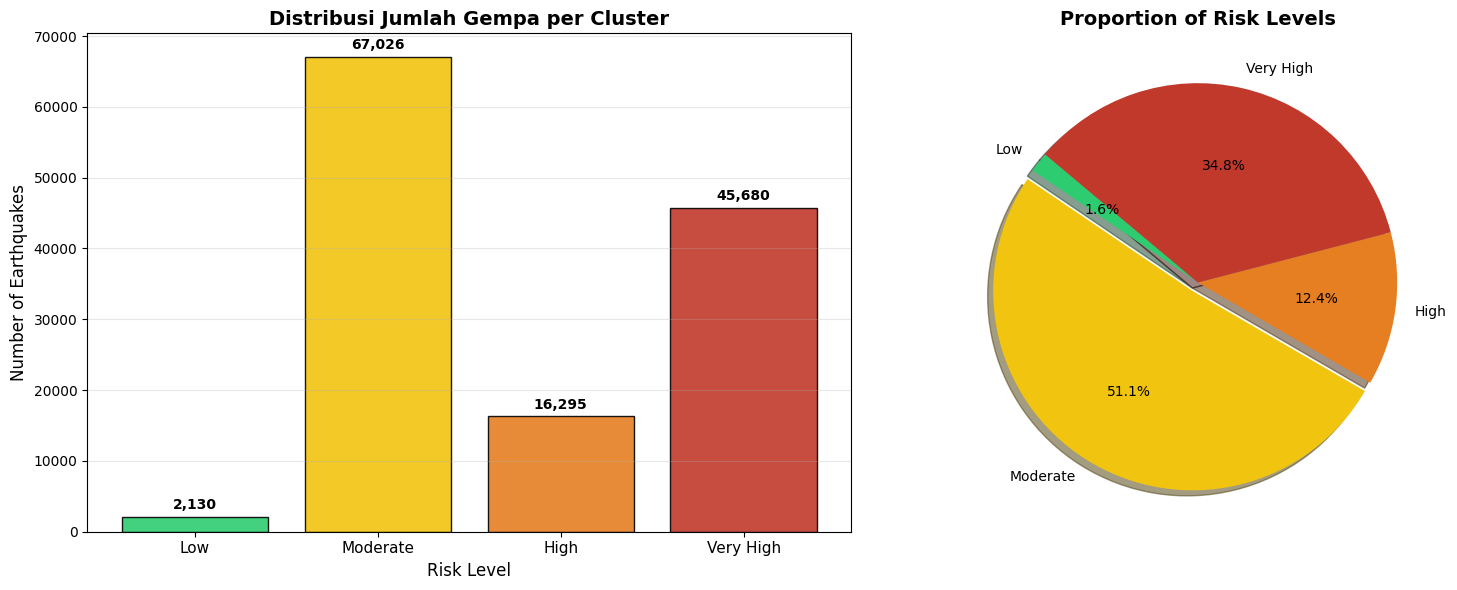

In [11]:
# Analisis Jumlah Anggota per Cluster (FIXED ORDER)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define labels explicitly based on our new sorted IDs (0=Low, 1=Mod, 2=High, 3=VH)
risk_labels = ['Low', 'Moderate', 'High', 'Very High']
if 'best_k' in locals() and best_k != 4:
    risk_labels = [f'Level {i+1}' for i in range(best_k)]

# Hitung jumlah anggota per cluster
cluster_counts = df['cluster'].value_counts().sort_index()

print("=" * 60)
print(f"{'CLUSTER':<10} | {'RISK LEVEL':<12} | {'COUNT':>8} | {'PERCENT':>7}")
print("=" * 60)

total = len(df)
for i in range(len(risk_labels)):
    count = cluster_counts.get(i, 0)
    pct = (count / total) * 100
    lbl = risk_labels[i]
    print(f"{i:<10} | {lbl:<12} | {count:>8,d} | {pct:>6.1f}%")

print("=" * 60)
print(f"{'TOTAL':<25} | {total:>8,d} | 100.0%")
print("=" * 60)

# --- VISUALIZATION ---
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b'] # Green -> Red
if len(risk_labels) > 4:
    colors = sns.color_palette("viridis", len(risk_labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar Chart
x = range(len(risk_labels))
counts = [cluster_counts.get(i, 0) for i in x]

bars = axes[0].bar(x, counts, color=colors, edgecolor='black', alpha=0.9)
axes[0].set_xlabel('Risk Level', fontsize=12)
axes[0].set_ylabel('Number of Earthquakes', fontsize=12)
axes[0].set_title('Distribusi Jumlah Gempa per Cluster', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(risk_labels, fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + (max(counts)*0.01),
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 2. Pie Chart
explode = [0.05 if c == max(counts) else 0 for c in counts]
axes[1].pie(counts, labels=risk_labels, autopct='%1.1f%%', startangle=140, 
            colors=colors, explode=explode, shadow=True)
axes[1].set_title('Proportion of Risk Levels', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


evaluation

In [12]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score

# Pastikan X adalah data fitur yang digunakan untuk clustering (setelah normalisasi)
# dan labels adalah hasil dari model kmeans.labels_

# Evaluasi hasil klasterisasi
silhouette_avg = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
davies_bouldin = davies_bouldin_score(X_scaled, labels)
calinski_harabasz = calinski_harabasz_score(X_scaled, labels)

print("=== Evaluasi Model K-Means Clustering ===")
print(f"Silhouette Score       : {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index   : {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")

# Interpretasi singkat
print("\nKeterangan:")
print("- Silhouette Score yang lebih tinggi menandakan klaster lebih terpisah dengan baik.")
print("- Davies-Bouldin Index yang lebih rendah menunjukkan klaster lebih optimal.")
print("- Calinski-Harabasz Score yang lebih tinggi menandakan klaster yang lebih padat dan terpisah.")


=== Evaluasi Model K-Means Clustering ===
Silhouette Score       : 0.4699
Davies-Bouldin Index   : 0.7397
Calinski-Harabasz Score: 114080.2898

Keterangan:
- Silhouette Score yang lebih tinggi menandakan klaster lebih terpisah dengan baik.
- Davies-Bouldin Index yang lebih rendah menunjukkan klaster lebih optimal.
- Calinski-Harabasz Score yang lebih tinggi menandakan klaster yang lebih padat dan terpisah.


In [15]:
# 6. Save pipeline and cluster info
import joblib
from sklearn.pipeline import Pipeline

# Use cluster_summary (not cent_df)
print("Saving artifacts...")
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(kmeans, 'kmeans_model.joblib')
cluster_summary.to_csv('cluster_info.csv', index=False)
df.to_csv('earthquakes_with_cluster.csv', index=False)

# Save the remapping dict for external use if needed
import pickle
with open('cluster_remap.pkl', 'wb') as f:
    pickle.dump(cluster_remap, f)

print('✅ Saved: scaler.joblib, kmeans_model.joblib, cluster_info.csv, earthquakes_with_cluster.csv, cluster_remap.pkl')


Saving artifacts...
✅ Saved: scaler.joblib, kmeans_model.joblib, cluster_info.csv, earthquakes_with_cluster.csv, cluster_remap.pkl


In [17]:
# 7. PREDICTION DEMO (Data Baru)
print("\n" + "="*50)
print("🤖 CLUSTER PREDICTION DEMO")
print("="*50)

def predict_risk(magnitude, depth_km, scaler_model, kmeans_model, remap_dict):
    # 1. Preprocess
    # FIX: Use DataFrame with names to silence warnings
    input_data = pd.DataFrame([[magnitude, depth_km]], columns=['mag', 'depth'])
    # Important: Scaler expects same scaler used in training
    # (We assume 'scaler' and 'kmeans' are in memory)
    scaled_data = scaler_model.transform(input_data)
    
    # 2. Predict Raw Cluster
    raw_cluster = kmeans_model.predict(scaled_data)[0]
    
    # 3. Remap to Risk Level
    # Note: 'cluster_remap' maps (Original Raw Cluster -> New Sorted ID/Label)
    # The kmeans model predicts RAW cluster IDs based on initial training.
    
    if raw_cluster in remap_dict:
        new_info = remap_dict[raw_cluster]
        risk_label = new_info['label']
        risk_id = new_info['new_id']
    else:
        risk_label = "Unknown"
        risk_id = -1
        
    return risk_id, risk_label

# Test Cases
test_cases = [
    (3.0, 20.0, "Gempa Kecil Dangkal (Expect: Moderate)"),
    (5.5, 30.0, "Gempa Besar Dangkal (Expect: Very High)"),
    (4.5, 500.0, "Gempa Dalam (Expect: Low)") 
]

print(f"{'Mag':<5} | {'Depth':<6} | {'Risk Level':<12} | {'Description'}")
print("-"*70)

for mag, depth, desc in test_cases:
     rid, rlabel = predict_risk(mag, depth, scaler, kmeans, cluster_remap)
     print(f"{mag:<5.1f} | {depth:<6.1f} | {rlabel.upper():<12} | {desc}")

# ==========================================
# 🛑 COBA PREDIKSI DATA SENDIRI
# ==========================================
# 📝 Ganti angka di bawah ini sesuai data gempa yang ingin dicek:
my_mag = 5.2       # <--- Masukkan Magnitudo
my_depth = 100.0   # <--- Masukkan Kedalaman (km)

p_id, p_label = predict_risk(my_mag, my_depth, scaler, kmeans, cluster_remap)

print("\n" + "="*40)
print(f"🔍 HASIL PREDIKSI SINGLE DATA")
print("="*40)
print(f"Magnitudo : {my_mag}")
print(f"Kedalaman : {my_depth} km")
print(f"----------------------------------------")
print(f"CLUSTER   : {p_id}")
print(f"KATEGORI  : {p_label.upper()}")
print("="*40)



🤖 CLUSTER PREDICTION DEMO
Mag   | Depth  | Risk Level   | Description
----------------------------------------------------------------------
3.0   | 20.0   | MODERATE     | Gempa Kecil Dangkal (Expect: Moderate)
5.5   | 30.0   | VERY HIGH    | Gempa Besar Dangkal (Expect: Very High)
4.5   | 500.0  | LOW          | Gempa Dalam (Expect: Low)

🔍 HASIL PREDIKSI SINGLE DATA
Magnitudo : 5.2
Kedalaman : 100.0 km
----------------------------------------
CLUSTER   : 3
KATEGORI  : VERY HIGH


## Cara menjalankan
1. Jalankan notebook ini (Colab / Jupyter).  
2. Setelah menyimpan `kmeans_pipeline.joblib`, jalankan Streamlit app:  
   ```bash
   streamlit run streamlit_app.py

   ```